In [106]:
import string
import re
import matplotlib.pyplot as plt

In [121]:
def insert(stack, process_id, process_weight):
    num_to_letter_map = {i: letter for i, letter in enumerate(string.ascii_lowercase)}
    tags = [str(process_id)+num_to_letter_map[a] for a in range(process_weight)]
    min_len = min(stack, key=len)
    min_len_idx = stack.index(min_len)
    for tag in tags:
        stack[min_len_idx].append(tag)

def delete_from_list(list_of_tags, process_id):
    to_remove = []
    for tag in list_of_tags:
        num = ''.join(re.findall(r'[0-9]+', tag))
        if num == str(process_id):
            to_remove.append(tag)
    for tag in to_remove:
        list_of_tags.remove(tag)

def delete(stack, process_id):
    list_id = -1
    for list_of_tags in stack:
        for tag in list_of_tags:
            num = ''.join(re.findall(r'[0-9]+', tag))
            if num == str(process_id):
                list_id = stack.index(list_of_tags)
                break
        if list_id != -1:
            break
    if list_id < 0:
        print(f"Process with id {process_id} not found")
    else:
        delete_from_list(stack[list_id], process_id)
    
def find_last_tag_nums(list_of_tags):
    tag_str = ''.join(list_of_tags)
    tag_list = re.split(r'[a-z]+', tag_str)[:-1]
    counts = {i: tag_list.count(i) for i in set(tag_list)}
    #print(tag_str,tag_list,counts)
    return counts

def clear_extra_tags(stack, procs):
    num_to_letter_map = {i: letter for i, letter in enumerate(string.ascii_lowercase)}
    for list_of_tags in stack:
        if list_of_tags:
            max_true_tag = {str(a): num_to_letter_map[b-1] for a, b in procs.items()}
            to_remove = []
            for tag in list_of_tags:
                letter = ''.join(re.findall(r'[a-z]+', tag))
                num = ''.join(re.findall(r'[0-9]+', tag))
                if letter > max_true_tag[num]:
                    to_remove.append(tag)
            for tag in to_remove:
                list_of_tags.remove(tag)

def clear_ghost_tags(stack):
    for i in range(len(stack)):
        if len(stack[i]) > 0:
            if stack[i][0] == 'x':
                stack[i] = []


#ATTENTION: sorted functions might be replaced by search with lower complexity!
def balance(stack):
    num_to_letter_map = {i: letter for i, letter in enumerate(string.ascii_lowercase)}

    #b = len(stack)
    min_len = min(stack, key=len)
    min_len_idx = stack.index(min_len)
    max_elem_idx = -1
    max_elems = -1
    for i in range(len(stack)):
        num_elems = len(find_last_tag_nums(stack[i]))
        if num_elems > max_elems:
            max_elems = num_elems
            max_elem_idx = i    
    
    ##Move shortest process from list with most elements to shortest list
    if max_elems > 1 and len(stack[max_elem_idx]) > len(stack[min_len_idx]):
        shortest_idx = -1
        shortest_weight = -1
        if len(stack[max_elem_idx]) > 0:
            last_nums = find_last_tag_nums(stack[max_elem_idx])
            last_nums = dict(sorted(last_nums.items(), key=lambda item: item[1]))
            #print(last_nums)
            shortest_idx = list(last_nums.keys())[0]
            shortest_weight = last_nums[shortest_idx]
        #print(max_elem_idx,shortest_idx)
        delete_from_list(stack[max_elem_idx], shortest_idx)
        for i in range(shortest_weight):
            stack[min_len_idx].append(str(shortest_idx)+num_to_letter_map[i])

    max_len = max(stack, key=len)
    max_len_idx = stack.index(max_len)

    ##Balance the rest of the lists by adding tags to the shorter ones
    for i in range(len(stack)):
        if len(stack[i]) == 0:
            continue
        dif = len(stack[max_len_idx]) - len(stack[i])
        last_nums = find_last_tag_nums(stack[i])
        last_nums = dict(sorted(last_nums.items(), key=lambda item: item[1], reverse=True)) #Sort by value to give higer weighted elements more priority
        last_tags = [a+num_to_letter_map[b]+'r' for a,b in last_nums.items()]
        while dif > len(last_tags):
            last_nums = {k: v+1 for k, v in last_nums.items()}
            last_nums = dict(sorted(last_nums.items(), key=lambda item: item[1], reverse=True))
            last_tags += [a+num_to_letter_map[b]+'r' for a,b in last_nums.items()]
        #print(last_tags)

        k = 0
        #print(dif)
        for j in range(len(stack[i])-dif, len(stack[i])):
            stack[i].append(last_tags[k])
            #print(stack[i][j],end=' ')
            k = (k+1) % len(last_tags)
        #print(stack[i])
    
    #add ghost nodes
    for i in range(len(stack)):
        if len(stack[i]) == 0:
            stack[i] = ['x' for _ in range(len(stack[max_len_idx]))]
        

    

In [143]:
def circle_with_tag(x, y, tag, radius=0.1, border_color='black', text_color='black'):
    circle = plt.Circle((x, y), radius, fill=False, edgecolor=border_color)
    plt.gca().add_patch(circle)
    plt.text(x, y, tag, horizontalalignment='center', verticalalignment='center', color=text_color)

def arrow(x1, y1, x2, y2, head_length=0.1):
    plt.arrow(x1, y1, x2-x1, y2-y1, head_width=0.05, head_length=head_length, fc='lightblue', ec='gray')

def plot_process(b, process_id, process_weight, xpos=0, ypos=0, sign=''):
    plt.text(2*xpos, ypos/2, sign, horizontalalignment='center', verticalalignment='center', fontsize=12)
    ## Plot
    step = 0.5
    radius = 0.15
    hl = 0.1 # head length
    positions = []
    for i in range(process_weight*b):
        x = xpos + i*step
        y = ypos
        positions.append((x, y))
    for i in range(0,process_weight*b,b):
        x1 = positions[i][0]
        y1 = positions[i][1]
        x2 = x1+step
        y2 = y1
        circle_with_tag(x1, y1, str(process_id)+string.ascii_lowercase[i//b], radius)
        arrow(x1+radius, y1, x2-radius-hl, y2, head_length=hl)
        for j in range(1,b):
            x1 = positions[i+j][0]
            y1 = positions[i+j][1]
            x2 = x1+step
            y2 = y1
            circle_with_tag(x1, y1, 'x', radius)
            arrow(x1+radius, y1, x2-radius-hl, y2, head_length=hl)
            
    #plt.axis('equal')
    #plt.axis('off')
    #plt.show()

def plot_graph(stack, ypos=0, process=None, sign=''):
    len0 = len(stack[0])
    for i in range(1, len(stack)):
        if len(stack[i]) != len0:
            print("Cannot plot graph, lists have different lengths")
            return
    if len0 == 0:
        print("Cannot plot graph, lists are empty")
        return
    
    nodes = []
    for l in stack:
        if l:
            nodes += l
    edges = []
    for i in range(len0):
        for j in range(len(stack)-1):
            edges.append((stack[j][i], stack[j+1][i]))
        if i < len0-1:
            edges.append((stack[-1][i], stack[0][i+1]))
        #else:
        #    edges.append((stack[-1][i], stack[0][0]))
    
    ## Plot
    step = 0.5
    radius = 0.15
    hl = 0.1 # head length
    positions = []
    for i in range(len(nodes)):
        x = i*step
        y = ypos
        positions.append((x, y))
    for i in range(len(edges)):
        x1 = positions[i][0]
        y1 = positions[i][1]
        x2 = positions[i+1][0]
        y2 = positions[i+1][1]
        if edges[i][0][-1] == 'r':
            circle_with_tag(x1, y1, edges[i][0][:-1], radius, border_color='grey', text_color='grey')
        else:
            circle_with_tag(x1, y1, edges[i][0], radius)
        arrow(x1+radius, y1, x2-radius-hl, y2, head_length=hl)
    x1 = positions[len(edges)][0]
    y1 = positions[len(edges)][1]
    x2 = x1+step
    y2 = y1
    if edges[len(edges)-1][1][-1] == 'r':
        circle_with_tag(x1, y1, edges[len(edges)-1][1][:-1], radius, border_color='grey', text_color='grey')
    else:
        circle_with_tag(x1, y1, edges[len(edges)-1][1], radius)
    arrow(x1+radius, y1, x2-radius-hl, y2, head_length=hl)

    if process:
        plot_process(len(stack), process[0], process[1], xpos=positions[0][0], ypos=positions[0][1]-1, sign=sign)

    plt.axis('equal')
    plt.axis('off')
    plt.show()


Cannot plot graph, lists are empty
[['0a', '0b'], ['x', 'x'], ['x', 'x']]


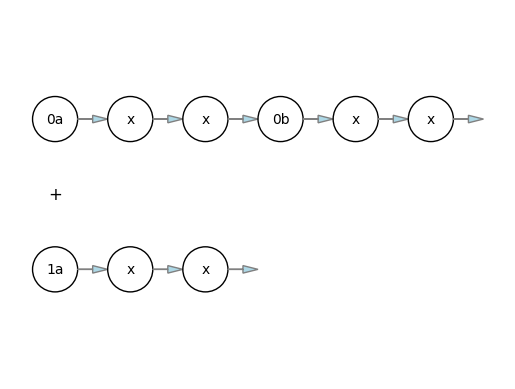

[['0a', '0b'], ['1a', '1br'], ['x', 'x']]


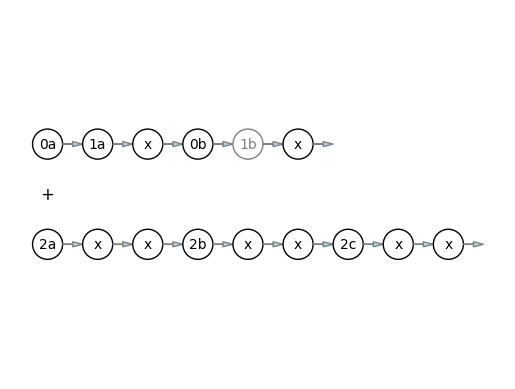

[['0a', '0b', '0cr'], ['1a', '1br', '1cr'], ['2a', '2b', '2c']]


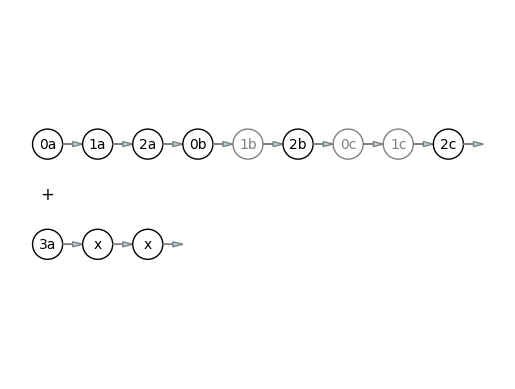

[['0a', '0b', '0cr'], ['1a', '3a', '1br'], ['2a', '2b', '2c']]


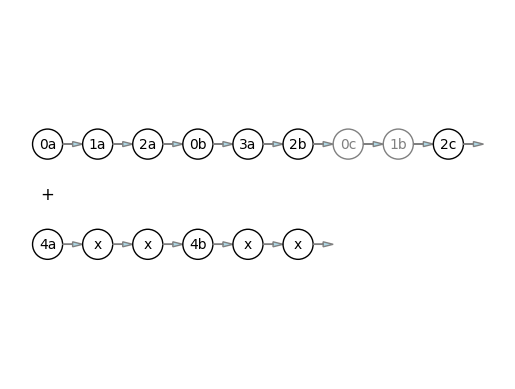

[['4a', '4b', '4cr', '4dr'], ['1a', '3a', '0a', '0b'], ['2a', '2b', '2c', '2dr']]


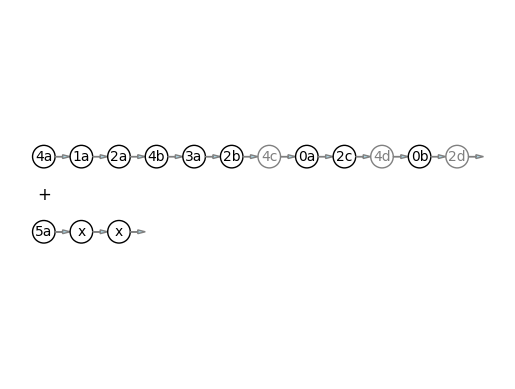

[['4a', '4b', '5a', '1a'], ['3a', '0a', '0b', '0cr'], ['2a', '2b', '2c', '2dr']]


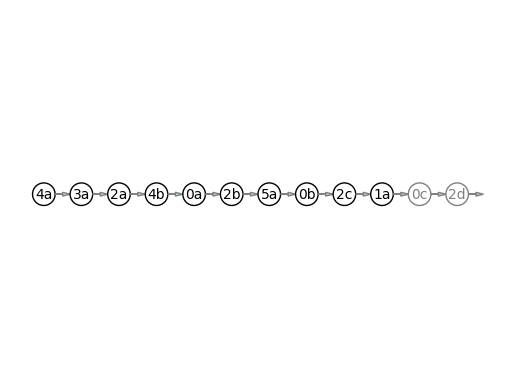

[['4a', '4b', '5a', '1a'], ['3a', '0a', '0b', '0cr'], ['2a', '2b', '2c', '2dr']]


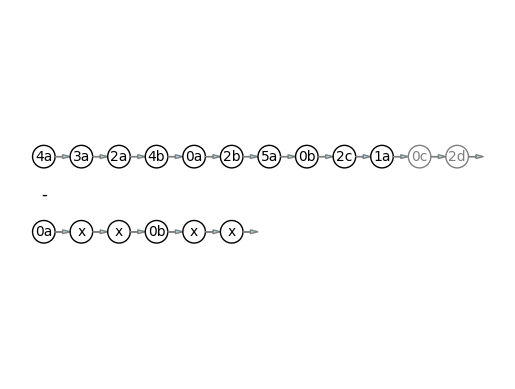

[['4a', '4b', '1a'], ['3a', '5a', '5br'], ['2a', '2b', '2c']]


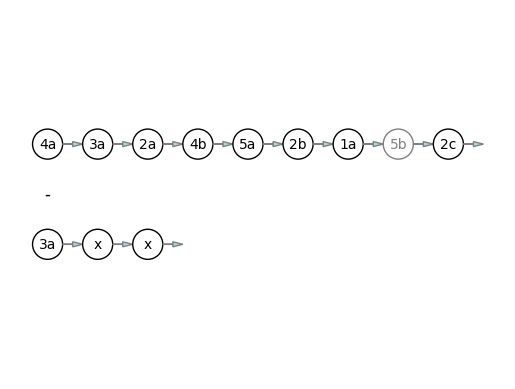

[['4a', '4b', '4cr'], ['5a', '1a', '1br'], ['2a', '2b', '2c']]


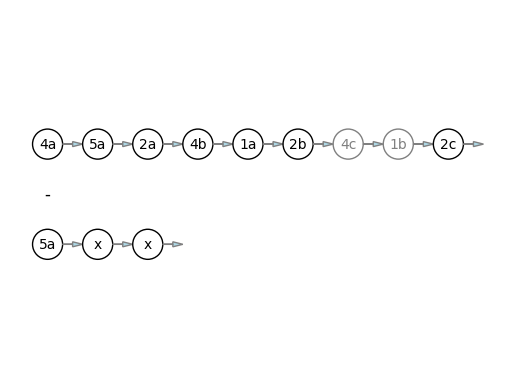

[['4a', '4b', '4cr'], ['1a', '1br', '1cr'], ['2a', '2b', '2c']]


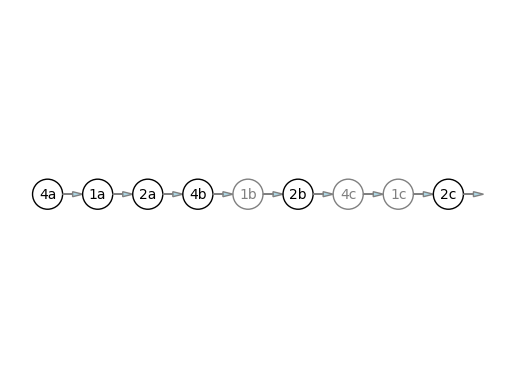

[['4a', '4b', '4cr'], ['1a', '1br', '1cr'], ['2a', '2b', '2c']]


In [144]:
proc = {0:2, 1:1, 2:3, 3:1, 4:2, 5:1}
b = 3
stack = [[] for _ in range(b)]

for p in proc:
    plot_graph(stack, ypos=0, process=(p, proc[p]), sign='+')
    #print(stack)
    clear_ghost_tags(stack)
    #print(stack)
    clear_extra_tags(stack, proc)
    #print(stack)
    insert(stack, p, proc[p])
    #print(stack)  
    balance(stack)
    print(stack)
    #print()
plot_graph(stack, ypos=0)
print(stack)
#print()

to_delete = [0, 3, 5]
for p in to_delete:
    plot_graph(stack, ypos=0, process=(p, proc[p]), sign='-')
    #print(stack)
    delete(stack, p)
    #print(stack)
    clear_ghost_tags(stack)
    #print(stack)
    clear_extra_tags(stack, proc)
    #print(stack)
    balance(stack)
    print(stack)
    #print()
plot_graph(stack, ypos=0)
print(stack)

In [110]:
proc = {0:5, 1:1, 2:1, 3:3, 4:1, 5:1}
N = len(proc)
b = 3

stack = [[] for _ in range(b)]
for p in proc:
    #print(stack)
    clear_ghost_tags(stack)
    #print(stack)
    clear_extra_tags(stack, proc)
    #print(stack)
    insert(stack, p, proc[p])
    #print(stack)  
    balance(stack)
    print(stack)
    print()
print()
print(stack)
print()

to_delete = [2, 3, 0, 1, 5, 4]
for p in to_delete:
    #print(stack)
    delete(stack, p)
    #print(stack)
    clear_ghost_tags(stack)
    #print(stack)
    clear_extra_tags(stack, proc)
    #print(stack)
    balance(stack)
    print(stack)
    print()
print()
print(stack)

[['0a', '0b', '0c', '0d', '0e'], ['x', 'x', 'x', 'x', 'x'], ['x', 'x', 'x', 'x', 'x']]

[['0a', '0b', '0c', '0d', '0e'], ['1a', '1b', '1cr', '1dr', '1er'], ['x', 'x', 'x', 'x', 'x']]

[['0a', '0b', '0c', '0d', '0e'], ['1a', '1b', '1cr', '1dr', '1er'], ['2a', '2b', '2cr', '2dr', '2er']]

[['0a', '0b', '0c', '0d', '0e'], ['3a', '3b', '3c', '3d', '3er'], ['2a', '1a', '1b', '2b', '1cr']]

[['0a', '0b', '0c', '0d', '0e'], ['3a', '3b', '3c', '3d', '3er'], ['2a', '1a', '4a', '1b', '2b']]

[['0a', '0b', '0c', '0d', '0e'], ['3a', '3b', '3c', '5a', '3d'], ['2a', '1a', '4a', '1b', '2b']]


[['0a', '0b', '0c', '0d', '0e'], ['3a', '3b', '3c', '5a', '3d'], ['2a', '1a', '4a', '1b', '2b']]

[['0a', '0b', '0c', '0d', '0e'], ['3a', '3b', '3c', '3d', '3er'], ['1a', '4a', '5a', '5b', '1b']]

[['0a', '0b', '0c', '0d', '0e'], ['5a', '5b', '5cr', '5dr', '5er'], ['1a', '4a', '1b', '4b', '1cr']]

[['1a'], ['5a'], ['4a']]

[['x'], ['5a'], ['4a']]

[['x'], ['x'], ['4a']]

[[], [], []]


[[], [], []]
